# Cone-linearized center-disc analysis
**The experiment.** This notebook combines `LinearEquivalentDiscConeLin` with the newer
`LinearEquivalentDisc` implementation. Both show each natural-image center patch three ways:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform center disc at the ordinary linear-equivalent intensity |
| `linConeIntensity` / `lin cone intensity` | uniform center disc at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

The older, same-named `LinearEquivalentDisc` class only alternated `image` and `intensity`.
It did not define `linearizeCones`; discovery therefore excludes those blocks from every
section below using their saved block metadata rather than a hard-coded date cutoff.

The nonlinearity index is computed per `(imageName, patchIndex)`:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

and is set to zero when neither response clears the recording-mode threshold.


In [1]:
import contextlib
import io
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.63 s


## 1. Find center-disc experiment dates and cells

Treat `LinearEquivalentDiscConeLin` and the newer, cone-linearizing
`LinearEquivalentDisc` as one center-disc analysis family. Each table row is one available
cell × resolved `onlineAnalysis` × numeric FilterWheel combination, so its values can be copied
directly into Section 2. The table also retains `cell_type_short` and the exact protocol name.
For `LinearEquivalentDisc`, blocks without a saved
`linearizeCones` parameter belong to the older two-stimulus implementation and are excluded
before dates or cells are listed.


In [2]:
CENTER_PROTOCOLS = (
    'LinearEquivalentDiscConeLin',
    'LinearEquivalentDisc',
)
PROTOCOL_LABEL = 'cone-linearized center disc'

protocol_blocks = led.find_blocks(protocols=CENTER_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    protocol_blocks = led.check_series_resistance(
        protocol_blocks, show=False, sample_series_resistance=True)
protocol_cells = (protocol_blocks[[
    'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'filter_wheel_ndf', 'protocol']]
    .drop_duplicates()
    .sort_values(['exp_name', 'cell_label', 'onlineAnalysis',
                  'filter_wheel_ndf', 'protocol'])
    .reset_index(drop=True))
protocol_cells.insert(
    0, 'date_index', pd.factorize(protocol_cells['exp_name'], sort=False)[0] + 1)
print(f'{PROTOCOL_LABEL}: {len(protocol_cells)} available conditions across '
      f'{protocol_cells.exp_name.nunique()} experiments')
sc.scroll_table(protocol_cells, height=420, num_cols=('filter_wheel_ndf',))


cone-linearized center disc: 86 available conditions across 27 experiments


date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,filter_wheel_ndf,protocol
1,2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
1,2026-03-09_E,Cell3,horizontal,exc,0.0,LinearEquivalentDisc
2,2026-03-10_E,Cell5,horizontal,exc,0.0,LinearEquivalentDisc
3,2026-03-17_E,Cell6,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
4,2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell2,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell3,horizontal,exc,0.0,LinearEquivalentDisc
6,2026-04-03_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
6,2026-04-03_E,Cell4,OFF-parasol,extracellular,0.0,LinearEquivalentDisc


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:420px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>filter_wheel_ndf</th><th>protocol</th></tr></thead><tbody><tr><td>1</td><td>2026-03-09_E</td><td>Cell1</td><td>OFF-

## 2. Analyze one cell condition

This section is standalone after the import cell: enter a `date_index` from Section 1 (or a
previously known index), cell label, resolved `onlineAnalysis`, and numeric FilterWheel value.
It performs its own date lookup and detailed block loading, so Section 1 does not need to be run
first. The first output lists the matching block IDs, aperture diameter, center RF sigma,
stimulus timing, and one row per `imageName`, including its epoch count and
`meanIntensity = maxIntensity × backgroundIntensity`.

Responses use the exact onset window from `preTime` through `preTime + stimTime`: spike count
for extracellular recordings and baseline-subtracted signed area (pA·s) for whole-cell
recordings. Each scatter point is one `(imageName, patchIndex)` pair; x and y error bars are
SEM across repeat epochs. The per-image and pooled figures show image vs standard disc in grey
and image vs cone-linearized disc in red, with a unity line. Patch indices that restart in a new
image remain separate. The final figure uses empirical NLI CDFs and a second panel with
the mean ± SEM across every image-specific patch for this cell. After Section 2a has saved this
exact block set once, rerunning after a kernel restart reloads those patch results instead of
re-reading traces and detecting spikes. Pass `reuse_saved=False` to `analyze_condition` when a
deliberate raw-data recomputation is needed. The final sanity-check panel shows a few
response-selected `(imageName, patchIndex)` examples: trial-normalized PSTHs for
extracellular recordings, or baseline-subtracted mean traces for `exc`/`inh`.

2026-03-09_E/Cell1 | extracellular | FilterWheel 0
block_ids: 36854
1 imageNames | 90 epochs


imageName,block_ids,epochs,maxIntensity,backgroundIntensity,meanIntensity
01151,[36854],90,25000.0,0.1822633339669877,4556.583349174693


loaded 20 saved patch arrays from /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/2026-03-09_E__Cell1__extracellular__center__LinearEquivalentDisc__FW0.h5


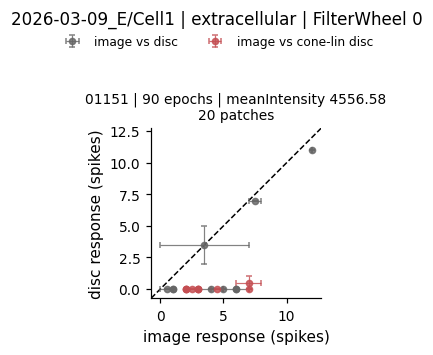

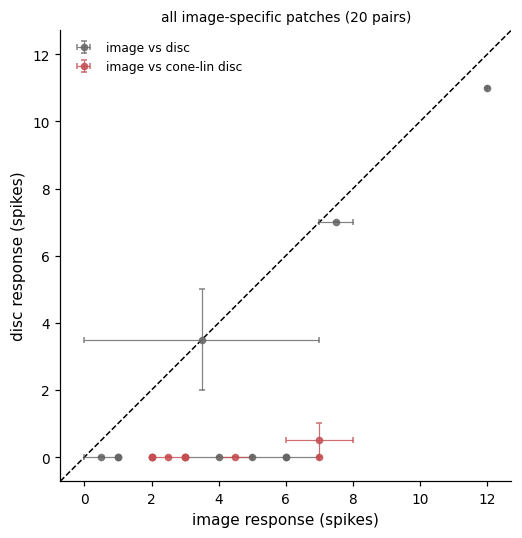

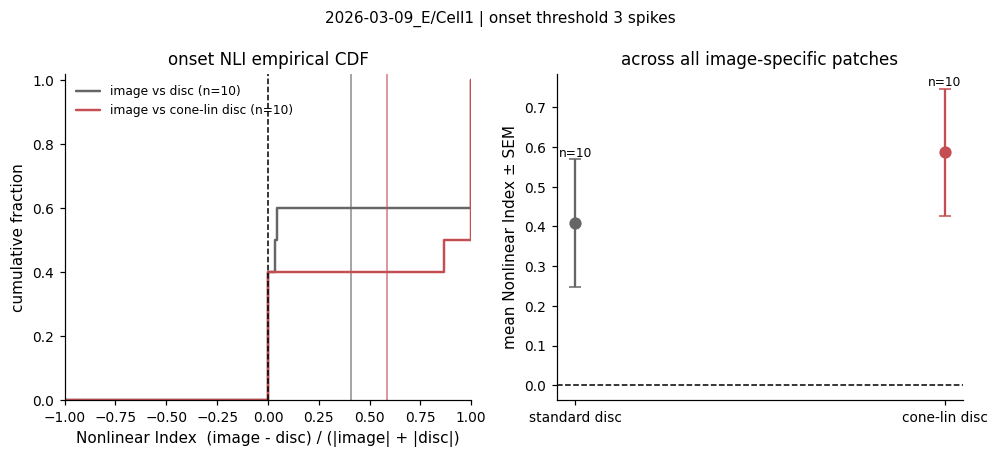

In [5]:
# Standalone after the imports; Section 1 is optional.
CENTER_PROTOCOLS = (
    'LinearEquivalentDiscConeLin',
    'LinearEquivalentDisc',
)
PROTOCOL_LABEL = 'cone-linearized center disc'
DATE_INDEX = 8
CELL_LABEL = 'Cell1'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
FILTER_WHEEL_VALUE = 0.5          # authoritative numeric FilterWheel value

analysis_dates = led.find_protocol_cells(CENTER_PROTOCOLS, show=False)
analysis_dates.insert(
    0, 'date_index', pd.factorize(analysis_dates['exp_name'], sort=False)[0] + 1)
date_rows = analysis_dates.loc[analysis_dates.date_index.eq(DATE_INDEX)]
if date_rows.empty:
    raise ValueError(f'date_index {DATE_INDEX} is not available for {PROTOCOL_LABEL}')
EXP_NAME = date_rows.exp_name.iloc[0]

df_blocks = led.find_blocks(
    exp_names=[EXP_NAME], protocols=CENTER_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    df_blocks = led.check_series_resistance(
        df_blocks, show=False, sample_series_resistance=True)
selected_blocks = df_blocks.copy()
if selected_blocks.empty:
    raise ValueError(f'{EXP_NAME!r} has no cone-linearized center-disc blocks')

condition_blocks = led.select_condition_blocks(
    selected_blocks, CELL_LABEL, ONLINE_ANALYSIS, FILTER_WHEEL_VALUE)
key_parameters = (condition_blocks[[
    'apertureDiameter', 'rfSigmaCenter', 'preTime', 'stimTime', 'tailTime']]
    .drop_duplicates().reset_index(drop=True))
print('Key protocol parameters:')
print(key_parameters.to_string(index=False))
condition = led.analyze_condition(condition_blocks)
image_fig, pooled_fig, nli_fig = led.plot_condition(condition)
sample_psth_fig = led.plot_condition_sample_psths(
    condition_blocks, condition, n_pairs=3)

### 2a. Save this cell for population analysis

Save one compressed HDF5 record for the selected cell condition, similar to a MATLAB struct
containing arrays. Cell metadata is stored once, and the image summary and patch responses are
kept as typed arrays instead of tens of thousands of CSV rows. `condition_population_table()`
still expands the selected condition for display when needed. Each distinct date/cell/mode/FW
condition gets its own file; rerunning that exact condition replaces its file rather than
duplicating it. The file also becomes the fast restart source for Section 2 when the selected
block IDs match. Later,
`led.load_condition_outputs()` combines every saved cell into one population table.

In [6]:
condition_output_path = led.save_condition_output(condition)
population_ready = led.condition_population_table(condition)
sc.scroll_table(
    population_ready, height=360,
    num_cols=('filter_wheel_ndf', 'patchIndex', 'maxIntensity',
              'meanIntensity', 'image_response', 'disc_response',
              'cone_disc_response', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc'));

saved 1 condition (20 patches as arrays) to /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/2026-03-09_E__Cell1__extracellular__center__LinearEquivalentDisc__FW0.h5


date,cell_label,cell_type,onlineAnalysis,protocol,site,filter_wheel_ndf,imageName,patchIndex,patch_key,block_ids,image_epochs,maxIntensity,backgroundIntensity,meanIntensity,response_units,image_response,image_response_sem,image_trials,disc_response,disc_response_sem,disc_trials,cone_disc_response,cone_disc_response_sem,cone_disc_trials,nli_image_vs_disc,nli_image_vs_cone_disc,output_version
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,1.0,01151:1,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,3.5,3.4999999999999996,2.0,3.5,1.4999999999999998,2.0,,,,0.0,,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,2.0,01151:2,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,3.0,0.0,2.0,,,,0.0,0.0,2.0,,1.0,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,4.0,01151:4,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,6.0,1.0,2.0,0.0,0.0,2.0,,,,1.0,,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,5.0,01151:5,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,7.0,1.0,2.0,,,,0.5,0.5,2.0,,0.8666666666666667,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,7.0,01151:7,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,4.0,1.0,2.0,0.0,0.0,2.0,,,,1.0,,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,8.0,01151:8,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,2.5,0.5,2.0,,,,0.0,0.0,2.0,,0.0,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,10.0,01151:10,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,7.5,0.5,2.0,7.0,0.0,2.0,,,,0.034482758620689655,,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,11.0,01151:11,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,4.5,0.5,2.0,,,,0.0,0.0,2.0,,1.0,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,13.0,01151:13,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,0.5,0.5,2.0,0.0,0.0,2.0,,,,0.0,,1
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,center,0.0,01151,14.0,01151:14,36854,90,25000.0,0.1822633339669877,4556.583349174693,spikes,2.0,0.0,2.0,,,,0.0,0.0,2.0,,0.0,1


### 2b. Check saved cells

Read only the small metadata attributes from saved center-disc conditions—without loading the
patch arrays—and list date, cell label/type, resolved `onlineAnalysis`, and FilterWheel value.

In [7]:
saved_cells = led.load_condition_index(protocol=CENTER_PROTOCOLS)
print(f'{len(saved_cells)} saved cell condition(s)')
sc.scroll_table(saved_cells, height=300, num_cols=('filter_wheel_ndf',));

1 saved cell condition(s)


date,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0


## 3. Population by image and cell type

Load saved HDF5 conditions from either center-disc protocol name. Each row is one cell ×
FilterWheel × `imageName`: `meanIntensity` is x, and the two y values are mean patch NLI for
the ordinary and cone-linearized disc comparisons. Then group rows into `[500, 1500)`,
`[1500, 3500)`, `[3500, 6000)`, and `[6000, 20000]` within each cell type and plot population
mean NLI ± SEM. No averaging occurs across cells before this grouping.


1 cell/image rows from 1 cells


exp_name,cell_label,cell_type,onlineAnalysis,protocol,filter_wheel_ndf,imageName,meanIntensity,n_patches,mean_nli_disc,mean_nli_cone_disc
2026-03-09_E,Cell1,OFF-parasol,extracellular,LinearEquivalentDisc,0.0,01151,4556.583349174693,20,0.4077961019490255,0.5866666666666667


1 of 1 rows are within 500–20000


cell_type,light_level,light_min,light_max,meanIntensity,n_cells,n_cell_images,mean_nli_disc,sem_nli_disc,mean_nli_cone_disc,sem_nli_cone_disc
OFF-parasol,3500-6000,3500.0,6000.0,4556.583349174693,1,1,0.4077961019490255,,0.5866666666666667,


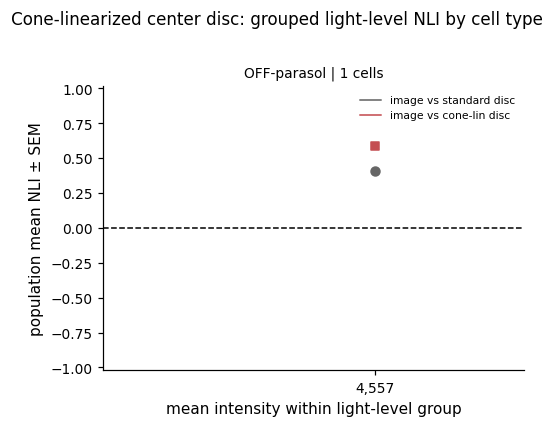

In [8]:
image_nli = led.load_condition_image_nli_summary(
    protocol=CENTER_PROTOCOLS)
print(f'{len(image_nli)} cell/image rows from {image_nli.cell_id.nunique()} cells')
image_nli_view = image_nli[[
    'exp_name', 'cell_label', 'cell_type', 'onlineAnalysis', 'protocol',
    'filter_wheel_ndf', 'imageName', 'meanIntensity', 'n_patches',
    'mean_nli_disc', 'mean_nli_cone_disc']]
sc.scroll_table(
    image_nli_view, height=360,
    num_cols=('filter_wheel_ndf', 'meanIntensity', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
light_level_nli = led.summarize_image_nli_light_levels(image_nli)
print(f'{light_level_nli.n_cell_images.sum()} of {len(image_nli)} rows are within 500–20000')
sc.scroll_table(
    light_level_nli, height=300,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_cells',
              'n_cell_images', 'mean_nli_disc', 'sem_nli_disc',
              'mean_nli_cone_disc', 'sem_nli_cone_disc'))
led.plot_image_nli_by_cell_type(
    image_nli, title_prefix='Cone-linearized center disc');


### 3a. Pooled patch NLI distributions

Pool every patch NLI from saved center-disc HDF5 conditions, without averaging by image or cell.
The first figure compares ordinary and cone-linearized discs across all saved patches. The second
repeats the normalized 50-bin density and empirical CDF separately for each cell type.


10 standard and 10 cone-lin patch NLIs from 20 saved rows and 1 cells


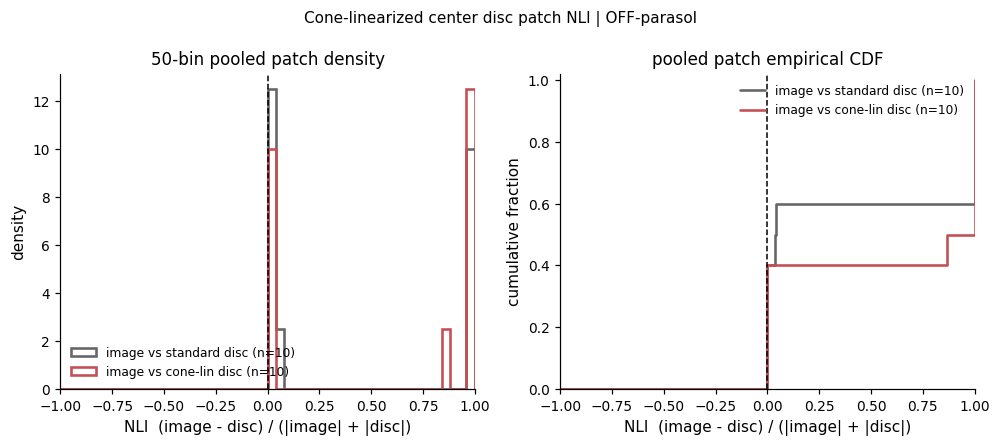

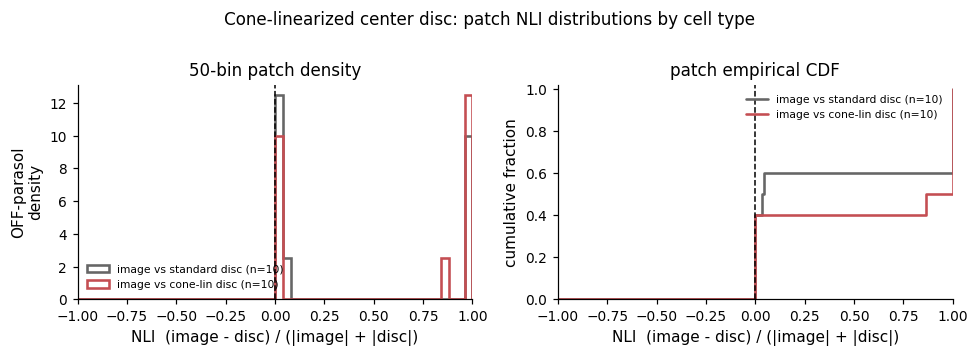

In [9]:
patch_nli = led.load_condition_patch_nli(
    protocol=CENTER_PROTOCOLS)
finite_patch_nli = np.isfinite(
    patch_nli[['nli_disc', 'nli_cone_disc']]).sum()
print(f"{finite_patch_nli['nli_disc']} standard and "
      f"{finite_patch_nli['nli_cone_disc']} cone-lin patch NLIs from "
      f'{len(patch_nli)} saved rows and {patch_nli.cell_id.nunique()} cells')
led.plot_pooled_patch_nli_distributions(
    patch_nli, bins=50, title_prefix='Cone-linearized center disc');
led.plot_patch_nli_distributions_by_cell_type(
    patch_nli, bins=50, title_prefix='Cone-linearized center disc');


### 3b. Cell-level averages by light level and paired high-light comparison

For each cell, pool all patches across all `imageName`s within `[500, 1500)` (~1k) or
`[6000, 20000]` (~10k), then calculate one ordinary-disc and one cone-linearized mean NLI.
Faint points are those cell means; large points and error bars are population mean ± SEM
across cells, so a cell with more patches does not get extra population weight. Finally, for
each cell type, the paired plot pools every patch at 7000 R* and above into one ordinary-disc
mean and one cone-linearized-disc mean per cell, then joins those two values with a line.


cell_type,cell_id,exp_name,cell_label,light_level,light_min,light_max,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc


cell_type,cell_id,exp_name,cell_label,min_intensity,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc


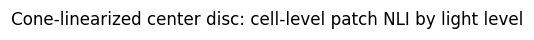

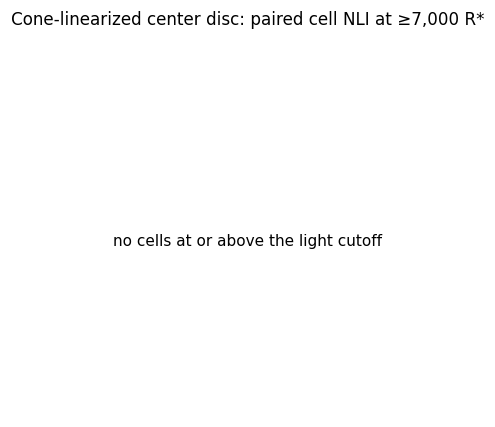

In [10]:
cell_light_nli = led.summarize_cell_patch_nli_light_levels(patch_nli)
sc.scroll_table(
    cell_light_nli, height=320,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_images',
              'n_patches', 'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_by_light(
    cell_light_nli, title_prefix='Cone-linearized center disc');
high_light_cell_nli = led.summarize_cell_patch_nli_above(
    patch_nli, min_intensity=7000)
sc.scroll_table(
    high_light_cell_nli, height=300,
    num_cols=('min_intensity', 'meanIntensity', 'n_images', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_paired_above(
    high_light_cell_nli, min_intensity=7000,
    title_prefix='Cone-linearized center disc');


## 4. Inspect selected date metadata (optional)

This optional section uses the date already loaded in Section 2 and groups its recordings by
cell, resolved recording mode, center-disc site, and light setting. It is not required for the
single-cell or population analyses above.

In [6]:
groups = led.group_blocks(selected_blocks)

1 recording groups (experiment x cell x mode x site x light level)


exp_name,cell_label,cell_type_short,onlineAnalysis,site,light_settings,block_ids,image_names,protocols,maxIntensity
2026-03-10_E,Cell5,horizontal,exc,center,FW0/bg0.182263,"36881, 36882",['01151'],LinearEquivalentDisc,25000.0


### 4a. Preview recorded stimuli

This optional visualization uses the date already loaded in Section 2. The dropdown contains
every recorded `imageName` for that date; choosing one redraws several recorded patches as a
tilted flash sequence. Each triplet proceeds from natural-image patch to linear-equivalent disc
to cone-linearized disc, and the diagonal time arrow shows the repeated presentation order.
Spatial x/y arrows follow the tilted edges of the first stimulus plane. As in the original
center-disc protocol, the full canvas stays at the recorded `backgroundIntensity`; only the
circular `apertureDiameter` region changes among the three stimulus classes. All stimuli use a
common grey scale. The image is loaded from the van Hateren resources in the turner package as
`NaturalImageFlashProtocol.m` does.

A useful geometry check: the mean intensity inside the center aperture should match the
recorded `equivalentIntensity`.

In [4]:
image_example = led.stimulus_example_widget(selected_blocks, sequence_length=4)
image_example